## Feature Extraction Techniques

### 1. Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique used to find a linear combination of features that separates two or more classes of objects or events. The goal of LDA is to maximize the ratio of between-class variance to within-class variance, thereby maximizing class separability. In this example, we apply LDA to the Iris dataset to project the data onto two dimensions (since there are three classes, the maximum number of components is `classes - 1`). The resulting plot visualizes how well the classes are separated in the new LDA-transformed space.

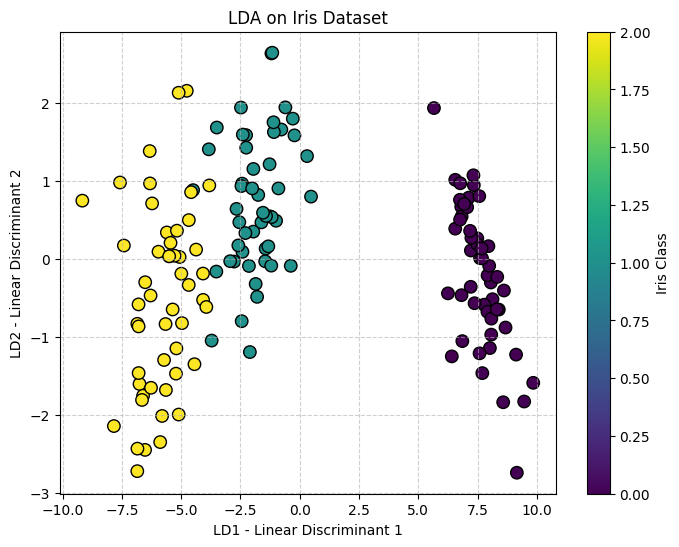

In [1]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Apply LDA (max components = classes-1 → 2 for Iris dataset)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# Plot the LDA-transformed data
plt.figure(figsize=(8, 6))
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', edgecolor='k', s=80)
plt.xlabel("LD1 - Linear Discriminant 1")
plt.ylabel("LD2 - Linear Discriminant 2")
plt.title("LDA on Iris Dataset")
plt.colorbar(label='Iris Class')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 2. Singular Value Decomposition (SVD)

Singular Value Decomposition (SVD) is a powerful matrix factorization technique that decomposes a matrix into three other matrices. In the context of feature extraction, SVD can be used to reduce the dimensionality of the data by retaining only the most significant singular values and their corresponding singular vectors. Here, we apply SVD to the Iris dataset and project the data onto its first two principal components (derived from SVD) for visualization. The singular values themselves indicate the importance of each dimension.

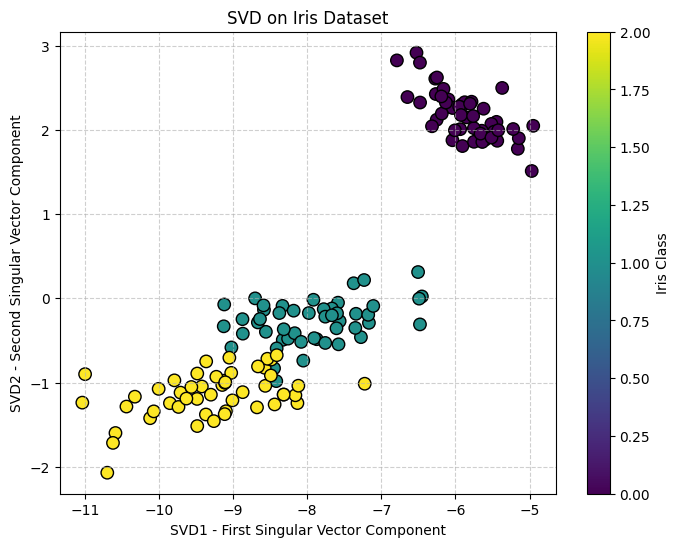

Singular values: [95.95991387 17.76103366  3.46093093  1.88482631]


In [2]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = iris.data
y = iris.target # Get target for coloring the plot

# Apply SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)

# Reduce to 2 components for visualization
# We take the first two columns of U and scale by the first two singular values.
# This projects the data onto the principal components derived from SVD.
X_svd = U[:, :2] @ np.diag(S[:2])

# Plot the SVD-transformed data
plt.figure(figsize=(8, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y, cmap='viridis', edgecolor='k', s=80)
plt.xlabel("SVD1 - First Singular Vector Component")
plt.ylabel("SVD2 - Second Singular Vector Component")
plt.title("SVD on Iris Dataset")
plt.colorbar(label='Iris Class')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Singular values
print("Singular values:", S)

### 3. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that transforms the data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. We first standardize the data (a common practice for PCA) and then apply PCA to reduce it to two principal components. The explained variance ratio tells us how much variance each component captures, and the plot visualizes the data in this new 2D space.

Explained variance ratio (PC1, PC2):
[0.72962445 0.22850762]
Total explained variance by 2 components: 0.96


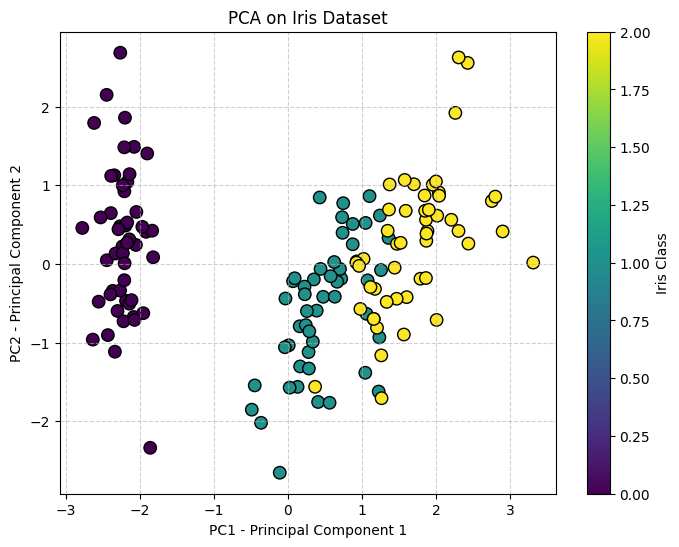

In [3]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Standardize Data (Although PCA can be applied directly, standardizing is good practice for comparability)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Print explained variance ratio for each component
print("Explained variance ratio (PC1, PC2):")
print(pca.explained_variance_ratio_)
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2f}")

# Plot the PCA-transformed data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=80)
plt.xlabel("PC1 - Principal Component 1")
plt.ylabel("PC2 - Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.colorbar(label='Iris Class')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4. Feature Subset Selection: Recursive Feature Elimination (RFE)

Feature Subset Selection aims to identify a subset of the most relevant features for model construction, removing redundant or irrelevant features. Recursive Feature Elimination (RFE) is a wrapper-type feature selection algorithm. It works by recursively training a model (estimator) and eliminating the least important features until the desired number of features is reached. In this example, we use Logistic Regression as the estimator and RFE to select the top 2 features from the Iris dataset, printing the original features, selected features, and their rankings.

In [4]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
import pandas as pd

# Load data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Initialize a base estimator (e.g., Logistic Regression)
estimator = LogisticRegression(solver='liblinear', random_state=42)

# Initialize RFE to select the top 2 features
# RFE works by recursively training the estimator and eliminating the least important features.
rfe = RFE(estimator=estimator, n_features_to_select=2, step=1)

# Fit RFE to the data
rfe.fit(X, y)

# Get the selected features
selected_features_mask = rfe.support_
selected_feature_indices = [i for i, x in enumerate(selected_features_mask) if x]
selected_feature_names = [feature_names[i] for i in selected_feature_indices]

print("Original features:", feature_names)
print("Selected features by RFE:", selected_feature_names)
print("Feature rankings (1 being the most important):")
# Display feature rankings
for i, rank in enumerate(rfe.ranking_):
    print(f"  {feature_names[i]}: Rank {rank}")

# Transform the data to include only the selected features
X_rfe = rfe.transform(X)

# Display the first 5 rows of the transformed data
print("\nFirst 5 rows of data with selected features:")
display(pd.DataFrame(X_rfe, columns=selected_feature_names).head())

Original features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Selected features by RFE: ['sepal width (cm)', 'petal width (cm)']
Feature rankings (1 being the most important):
  sepal length (cm): Rank 3
  sepal width (cm): Rank 1
  petal length (cm): Rank 2
  petal width (cm): Rank 1

First 5 rows of data with selected features:


,sepal width (cm),petal width (cm)
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2
3,3.1,0.2
4,3.6,0.2
